In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/processed/supply_chain_clean.csv")

In [4]:
df.shape

(180519, 55)

In [5]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Shipping_Delay_Days,Order_Month
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,-1,2018-01
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,1,2018-01
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class,0,2018-01
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class,-1,2018-01
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class,-2,2018-01


In [6]:
df.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

# Supply Chain & Delivery Analytics — Exploratory Data Analysis

## 1. Overall Delivery Performance

In [7]:
delivery_counts = df['Delivery Status'].value_counts()
delivery_counts

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

In [8]:
delivery_pct = (
    df['Delivery Status']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

delivery_pct

Delivery Status
Late delivery        54.83
Advance shipping     23.04
Shipping on time     17.84
Shipping canceled     4.30
Name: proportion, dtype: float64

### Key Finding

Late delivery is the largest delivery-status category, accounting for 54.83% of dataset records. Advance shipping accounts for 23.04%, shipping on time for 17.84%, and shipping canceled for 4.30%.

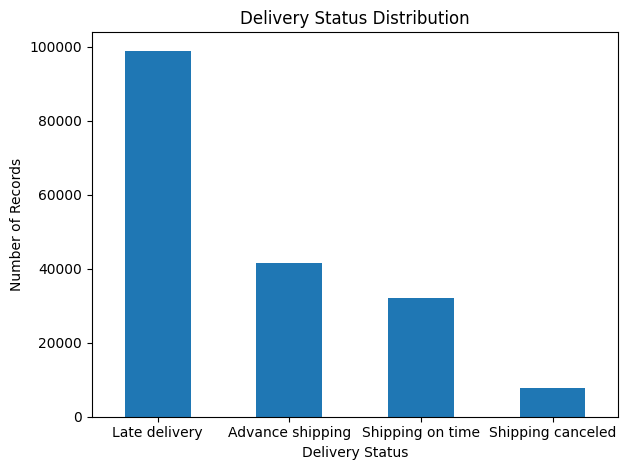

In [9]:
import matplotlib.pyplot as plt

delivery_counts.plot(kind='bar')

plt.title('Delivery Status Distribution')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 2. Shipping Mode Analysis


This section evaluates delivery performance across different shipping modes to identify whether certain modes have higher observed late-delivery rates.

In [10]:
late_by_shipping = (
    df.groupby('Shipping Mode')['Late_delivery_risk']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

late_by_shipping.round(2)

Shipping Mode
First Class       95.32
Second Class      76.63
Same Day          45.74
Standard Class    38.07
Name: Late_delivery_risk, dtype: float64

### Key Finding

First Class has the highest observed late-delivery rate at 95.32%, while Standard Class has the lowest at 38.07%. This represents a 57.25 percentage-point difference across shipping modes. The result indicates substantial variation in delivery performance across shipping modes, although it does not establish that shipping mode itself causes delays.

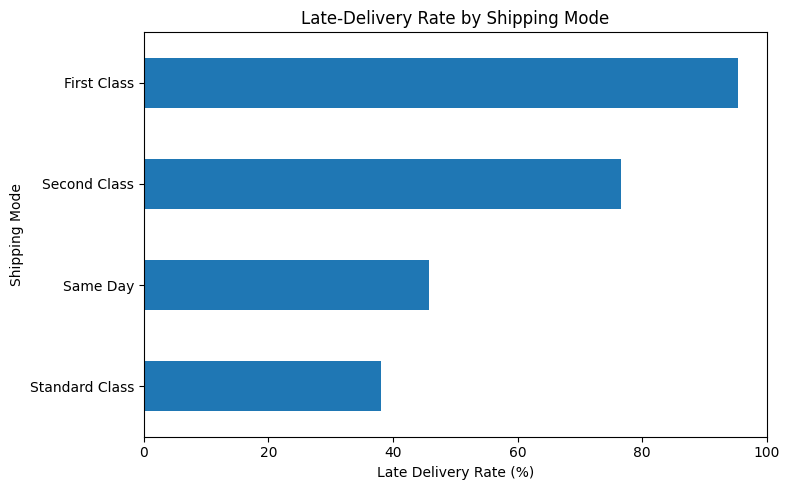

In [11]:
late_by_shipping.sort_values().plot(kind='barh', figsize=(8, 5))

plt.title('Late-Delivery Rate by Shipping Mode')
plt.xlabel('Late Delivery Rate (%)')
plt.ylabel('Shipping Mode')
plt.tight_layout()
plt.show()

In [12]:
profit_by_shipping = (
    df.groupby('Shipping Mode')['Order Profit Per Order']
    .mean()
    .sort_values(ascending=False)
)

profit_by_shipping.round(2)

Shipping Mode
First Class       23.12
Standard Class    22.00
Second Class      21.31
Same Day          20.85
Name: Order Profit Per Order, dtype: float64

### Profitability Finding

First Class has the highest average recorded profit per row at 23.12, while Same Day has the lowest at 20.85. The difference is relatively small compared with the large variation in late-delivery rates across shipping modes.

In [13]:
sales_by_shipping = (
    df.groupby('Shipping Mode')['Sales']
    .mean()
    .sort_values(ascending=False)
)

sales_by_shipping.round(2)

Shipping Mode
Standard Class    204.38
First Class       204.01
Second Class      202.90
Same Day          199.50
Name: Sales, dtype: float64

### Shipping Mode Summary

Shipping mode shows substantial variation in observed late-delivery rates, ranging from 38.07% for Standard Class to 95.32% for First Class. In contrast, average sales and profit vary relatively little across shipping modes. This suggests that shipping mode is more strongly differentiated by delivery performance than by the average financial metrics examined here.


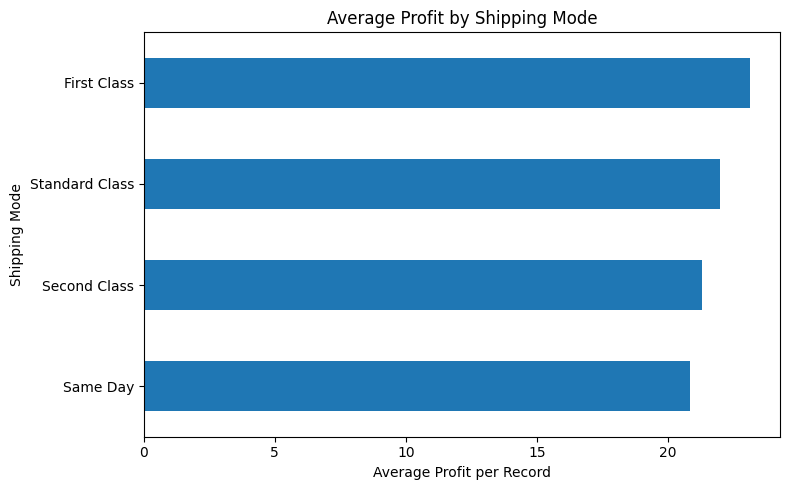

In [14]:
profit_by_shipping.sort_values().plot(
    kind='barh',
    figsize=(8, 5)
)

plt.title('Average Profit by Shipping Mode')
plt.xlabel('Average Profit per Record')
plt.ylabel('Shipping Mode')
plt.tight_layout()
plt.show()

## 3. Regional Analysis

This section evaluates delivery performance across order regions to identify geographic differences in observed late-delivery rates.

In [15]:
late_by_region = (
    df.groupby('Order Region')['Late_delivery_risk']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

late_by_region.round(2)

Order Region
Central Africa     57.96
South Asia         56.27
East Africa        55.94
Western Europe     55.85
South of  USA      55.77
Eastern Europe     55.66
East of USA        55.66
Southeast Asia     55.53
Central Asia       55.33
West Asia          55.28
US Center          55.24
Central America    54.75
North Africa       54.52
Southern Europe    54.38
Eastern Asia       54.33
South America      54.31
Northern Europe    54.04
Oceania            54.02
West of USA        53.96
Southern Africa    53.33
Caribbean          53.08
West Africa        52.84
Canada             48.80
Name: Late_delivery_risk, dtype: float64

In [16]:
top_5_regions = late_by_region.head(5).round(2)
top_5_regions

Order Region
Central Africa    57.96
South Asia        56.27
East Africa       55.94
Western Europe    55.85
South of  USA     55.77
Name: Late_delivery_risk, dtype: float64

In [17]:
bottom_5_regions = late_by_region.tail(5).sort_values().round(2)
bottom_5_regions

Order Region
Canada             48.80
West Africa        52.84
Caribbean          53.08
Southern Africa    53.33
West of USA        53.96
Name: Late_delivery_risk, dtype: float64

### Key Finding

Central Africa has the highest observed late-delivery rate at 57.96%, while Canada has the lowest at 48.80%. The difference between the highest and lowest regions is 9.16 percentage points, indicating that regional variation exists but is relatively modest compared with the variation observed across shipping modes.

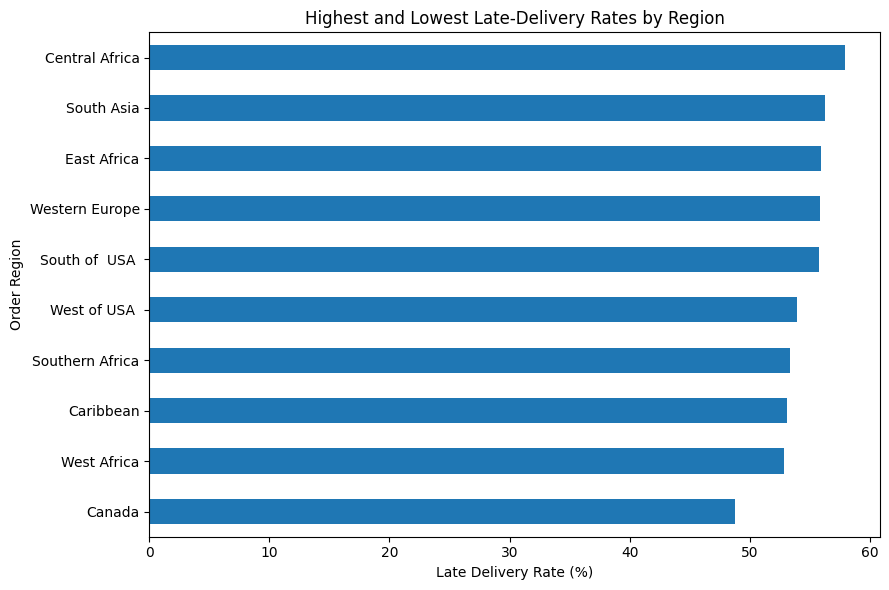

In [18]:
region_extremes = pd.concat([
    late_by_region.head(5),
    late_by_region.tail(5)
]).sort_values()

region_extremes.plot(
    kind='barh',
    figsize=(9, 6)
)

plt.title('Highest and Lowest Late-Delivery Rates by Region')
plt.xlabel('Late Delivery Rate (%)')
plt.ylabel('Order Region')
plt.tight_layout()
plt.show()

## 4. Product Category Analysis

This section evaluates delivery performance and financial contribution across product categories to identify categories with higher delivery risk and greater business importance.

In [19]:
late_by_category = (
    df.groupby('Category Name')['Late_delivery_risk']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

late_by_category.round(2)

Category Name
Golf Bags & Carts       68.85
Lacrosse                60.06
Pet Supplies            58.94
Cameras                 58.11
Strength Training       57.66
As Seen on  TV!         57.35
Music                   57.14
Accessories             56.97
Fitness Accessories     56.96
Books                   56.54
Women's Clothing        56.46
Boxing & MMA            56.26
Golf Gloves             56.26
Hunting & Shooting      56.14
Electronics             56.08
Crafts                  55.99
Health and Beauty       55.80
Tennis & Racquet        55.79
Garden                  55.79
Trade-In                55.65
Golf Shoes              55.53
Sporting Goods          55.46
Girls' Apparel          55.29
Basketball              55.22
Baseball & Softball     55.22
Consumer Electronics    55.22
Shop By Sport           55.15
Toys                    55.01
Cleats                  54.97
Fishing                 54.93
Water Sports            54.81
Indoor/Outdoor Games    54.75
Golf Balls              54

In [20]:
top_5_categories = late_by_category.head(5).round(2)
top_5_categories

Category Name
Golf Bags & Carts    68.85
Lacrosse             60.06
Pet Supplies         58.94
Cameras              58.11
Strength Training    57.66
Name: Late_delivery_risk, dtype: float64

In [21]:
bottom_5_categories = late_by_category.tail(5).sort_values().round(2)
bottom_5_categories

Category Name
Men's Golf Clubs    47.70
Computers           50.68
Golf Apparel        51.93
CDs                 52.03
Baby                52.66
Name: Late_delivery_risk, dtype: float64

### Key Finding

Golf Bags & Carts has the highest observed late-delivery rate at 68.85%, while Men's Golf Clubs has the lowest at 47.70%. The difference between the highest and lowest categories is 21.15 percentage points, indicating noticeable variation in delivery performance across product categories.


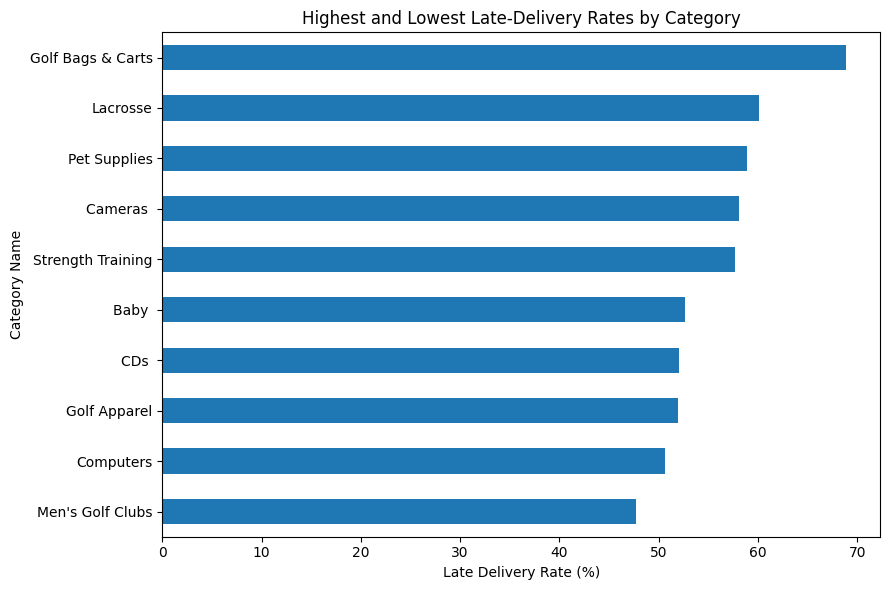

In [22]:
category_extremes = pd.concat([
    late_by_category.head(5),
    late_by_category.tail(5)
]).sort_values()

category_extremes.plot(
    kind='barh',
    figsize=(9, 6)
)

plt.title('Highest and Lowest Late-Delivery Rates by Category')
plt.xlabel('Late Delivery Rate (%)')
plt.ylabel('Category Name')
plt.tight_layout()
plt.show()

In [23]:
sales_by_category = (
    df.groupby('Category Name')['Sales']
    .sum()
    .sort_values(ascending=False)
)

sales_by_category.round(2)

Category Name
Fishing                 6929653.69
Cleats                  4431942.78
Camping & Hiking        4118425.57
Cardio Equipment        3694843.20
Women's Apparel         3147800.00
Water Sports            3113844.68
Men's Footwear          2891757.66
Indoor/Outdoor Games    2888993.91
Shop By Sport           1309522.04
Computers                663000.00
Electronics              371034.64
Cameras                  267607.69
Garden                   257768.73
Children's Clothing      232829.20
Crafts                   223356.33
Girls' Apparel           151706.20
Women's Clothing         140283.00
Accessories              133671.51
Sporting Goods           117006.75
Golf Gloves              116695.39
Music                    113122.10
Consumer Electronics     108991.28
Golf Shoes               107998.00
Health and Beauty        106080.48
Kids' Golf Clubs          98797.58
Baseball & Softball       94057.15
Boxing & MMA              85205.41
DVDs                      79395.54
Golf B

In [24]:
sales_by_category.head(5).round(2)

Category Name
Fishing             6929653.69
Cleats              4431942.78
Camping & Hiking    4118425.57
Cardio Equipment    3694843.20
Women's Apparel     3147800.00
Name: Sales, dtype: float64

In [25]:
profit_by_category = (
    df.groupby('Category Name')['Order Profit Per Order']
    .sum()
    .sort_values(ascending=False)
)

profit_by_category.round(2)

Category Name
Fishing                 756220.77
Cleats                  494636.92
Camping & Hiking        427455.57
Cardio Equipment        383011.10
Women's Apparel         350421.03
Water Sports            325146.96
Indoor/Outdoor Games    318451.43
Men's Footwear          311902.82
Shop By Sport           129813.96
Computers                69656.81
Electronics              40891.38
Garden                   33443.01
Cameras                  30289.80
Children's Clothing      27178.10
Crafts                   25531.17
Women's Clothing         19102.85
Girls' Apparel           17288.57
Accessories              16643.52
Music                    14436.32
Consumer Electronics     13223.40
Golf Gloves              12975.49
Baseball & Softball      12762.13
Sporting Goods           12518.61
Golf Shoes               12406.07
Health and Beauty         9493.63
Kids' Golf Clubs          9045.84
Boxing & MMA              8641.37
Golf Balls                8342.67
Trade-In                  7915.37


In [26]:
profit_by_category.head(5).round(2)

Category Name
Fishing             756220.77
Cleats              494636.92
Camping & Hiking    427455.57
Cardio Equipment    383011.10
Women's Apparel     350421.03
Name: Order Profit Per Order, dtype: float64

### Financial Finding

Fishing is the leading product category in both total sales and total recorded profit, followed by Cleats, Camping & Hiking, Cardio Equipment, and Women's Apparel. The same five categories rank highest for both metrics, indicating that the categories with the largest sales contributions also account for the largest recorded profit contributions.

In [27]:
category_summary = df.groupby('Category Name').agg(
    Late_Delivery_Rate=('Late_delivery_risk', 'mean'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Order Profit Per Order', 'sum')
)

category_summary['Late_Delivery_Rate'] *= 100

category_summary.round(2)

,Late_Delivery_Rate,Total_Sales,Total_Profit
Category Name,,,
Accessories,56.97,133671.51,16643.52
As Seen on TV!,57.35,20597.94,714.43
Baby,52.66,12229.56,1525.03
Baseball & Softball,55.22,94057.15,12762.13
Basketball,55.22,27099.33,1845.67
Books,56.54,12587.40,883.01
Boxing & MMA,56.26,85205.41,8641.37
CDs,52.03,3059.59,383.85
Cameras,58.11,267607.69,30289.80


In [28]:
category_summary.sort_values(
    'Total_Sales',
    ascending=False
).head(10).round(2)

,Late_Delivery_Rate,Total_Sales,Total_Profit
Category Name,,,
Fishing,54.93,6929653.69,756220.77
Cleats,54.97,4431942.78,494636.92
Camping & Hiking,54.53,4118425.57,427455.57
Cardio Equipment,54.50,3694843.20,383011.10
Women's Apparel,54.56,3147800.00,350421.03
Water Sports,54.81,3113844.68,325146.96
Men's Footwear,54.49,2891757.66,311902.82
Indoor/Outdoor Games,54.75,2888993.91,318451.43
Shop By Sport,55.15,1309522.04,129813.96


### Combined Category Finding

The highest-sales categories generally have late-delivery rates close to the overall dataset rate of 54.83%. Therefore, high sales volume alone does not appear to correspond to substantially higher observed delivery risk. Computers is an example of a financially contributing category with a comparatively lower late-delivery rate of 50.68%.

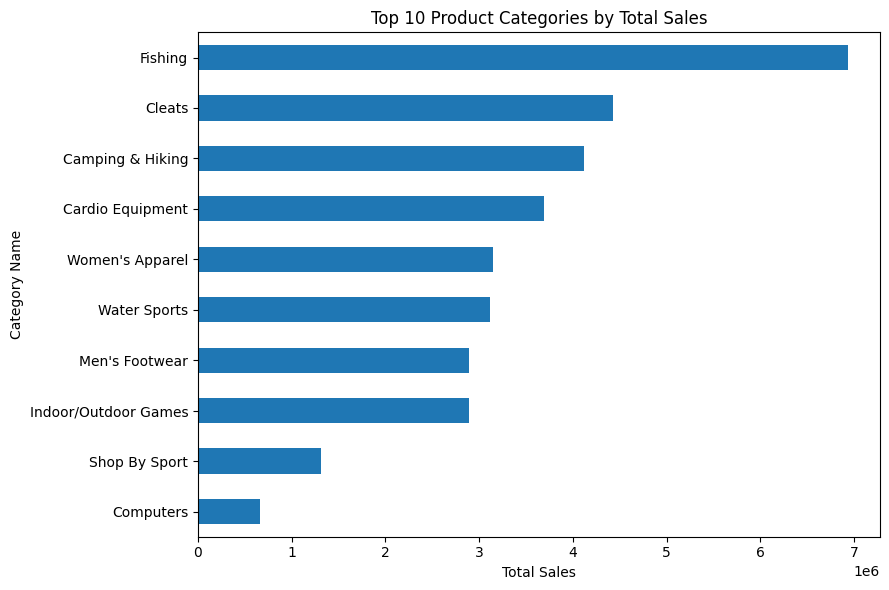

In [29]:
top_sales_categories = category_summary.sort_values(
    'Total_Sales',
    ascending=False
).head(10)

top_sales_categories['Total_Sales'].sort_values().plot(
    kind='barh',
    figsize=(9, 6)
)

plt.title('Top 10 Product Categories by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Category Name')
plt.tight_layout()
plt.show()

## 5. Customer Segment Analysis

This section evaluates delivery performance and financial metrics across customer segments to determine whether meaningful differences exist between segments.

In [30]:
late_by_segment = (
    df.groupby('Customer Segment')['Late_delivery_risk']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

late_by_segment.round(2)

Customer Segment
Home Office    55.07
Consumer       54.81
Corporate      54.72
Name: Late_delivery_risk, dtype: float64

### Key Finding

Late-delivery rates are very similar across customer segments. Home Office has the highest observed rate at 55.07%, while Corporate has the lowest at 54.72%, a difference of only 0.35 percentage points. This suggests that customer segment does not substantially differentiate late-delivery performance in this dataset.

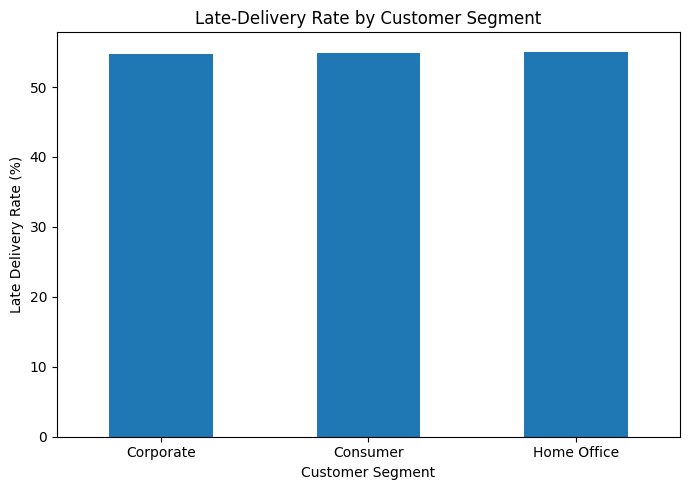

In [31]:
late_by_segment.sort_values().plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Late-Delivery Rate by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Average Sales by Customer Segment

In [32]:
sales_by_segment = (
    df.groupby('Customer Segment')['Sales']
    .mean()
    .sort_values(ascending=False)
)

sales_by_segment.round(2)

Customer Segment
Consumer       204.22
Corporate      203.84
Home Office    202.34
Name: Sales, dtype: float64

### Sales Finding

Consumer has the highest average Sales value at 204.22, while Home Office has the lowest at 202.34. The difference of 1.88 is small, indicating that average Sales values are also very similar across customer segments.

### Average Profit by Customer Segment

In [33]:
profit_by_segment = (
    df.groupby('Customer Segment')['Order Profit Per Order']
    .mean()
    .sort_values(ascending=False)
)

profit_by_segment.round(2)

Customer Segment
Consumer       22.18
Corporate      21.95
Home Office    21.44
Name: Order Profit Per Order, dtype: float64

### Profit Finding

Consumer has the highest average profit value at 22.18, while Home Office has the lowest at 21.44. The difference of 0.74 is relatively small, indicating that average profit is also broadly similar across customer segments.


### Customer Segment Summary

Customer segments show broadly similar delivery and financial performance. Late-delivery rates differ by only 0.35 percentage points, while average Sales differ by 1.88 and average profit differs by 0.74 between the highest and lowest segments. Overall, customer segment does not appear to be a major differentiating factor for delivery performance, average Sales, or average profit in this dataset.

## 6. Time-Based Analysis

This section examines monthly delivery performance to identify trends, peaks, or periods with unusually high or low late-delivery rates.

In [34]:
late_by_month = (
    df.groupby('Order_Month')['Late_delivery_risk']
    .mean()
    .mul(100)
)

late_by_month.round(2)


Order_Month
2015-01    54.11
2015-02    54.85
2015-03    54.76
2015-04    53.84
2015-05    55.09
2015-06    54.11
2015-07    55.46
2015-08    55.68
2015-09    56.69
2015-10    54.81
2015-11    54.27
2015-12    54.68
2016-01    55.58
2016-02    54.15
2016-03    55.76
2016-04    55.23
2016-05    55.66
2016-06    56.85
2016-07    51.93
2016-08    55.27
2016-09    54.98
2016-10    54.78
2016-11    54.63
2016-12    56.06
2017-01    53.61
2017-02    54.67
2017-03    55.26
2017-04    53.78
2017-05    53.47
2017-06    53.50
2017-07    54.78
2017-08    56.44
2017-09    54.23
2017-10    53.66
2017-11    55.09
2017-12    55.18
2018-01    56.29
Name: Late_delivery_risk, dtype: float64

### Key Finding

Monthly late-delivery rates remain relatively stable throughout the observed period, generally staying in the mid-50% range. June 2016 recorded the highest rate at 56.85%, while July 2016 recorded the lowest at 51.93%. Overall, the data does not show a clear long-term upward or downward trend in late-delivery performance.


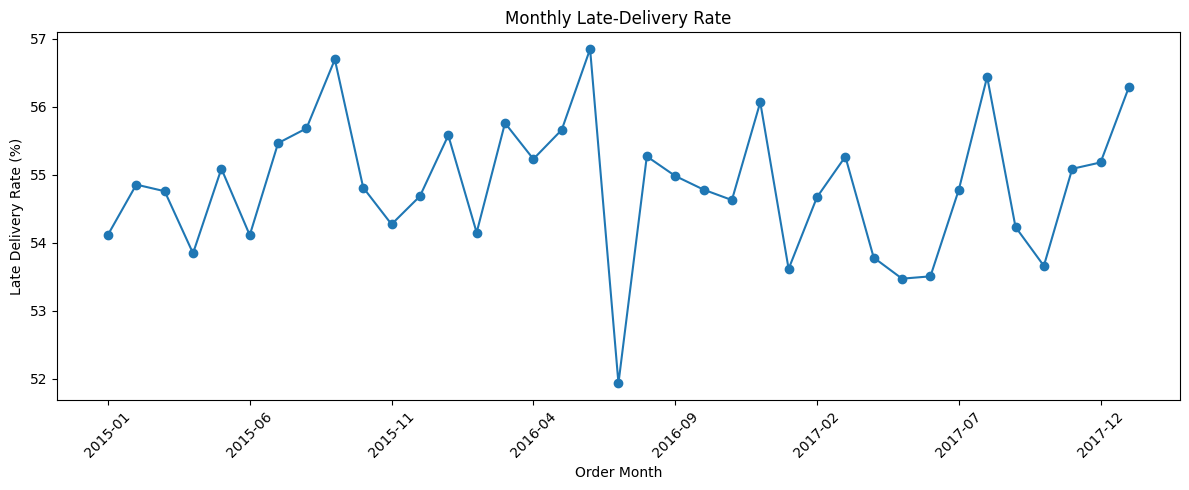

In [35]:
late_by_month.plot(
    kind='line',
    figsize=(12, 5),
    marker='o'
)

plt.title('Monthly Late-Delivery Rate')
plt.xlabel('Order Month')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Average Sales by Month

In [36]:
sales_by_month = (
    df.groupby('Order_Month')['Sales']
    .mean()
)

sales_by_month.round(2)

Order_Month
2015-01    197.59
2015-02    196.03
2015-03    196.06
2015-04    197.91
2015-05    196.09
2015-06    199.46
2015-07    195.90
2015-08    195.24
2015-09    198.12
2015-10    197.88
2015-11    196.58
2015-12    196.95
2016-01    196.79
2016-02    197.90
2016-03    196.90
2016-04    196.43
2016-05    194.15
2016-06    198.47
2016-07    197.12
2016-08    196.51
2016-09    194.26
2016-10    194.17
2016-11    201.07
2016-12    196.89
2017-01    197.37
2017-02    202.31
2017-03    196.00
2017-04    199.22
2017-05    207.92
2017-06    208.46
2017-07    207.67
2017-08    209.11
2017-09    220.42
2017-10    476.27
2017-11    305.07
2017-12    237.25
2018-01    156.22
Name: Sales, dtype: float64

### Key Finding

Average monthly Sales remain relatively stable through most of the observed period, generally staying around 194–209. A substantial increase occurs in late 2017, reaching 476.27 in October 2017, followed by 305.07 in November and 237.25 in December. Average Sales then fall to 156.22 in January 2018. This sharp fluctuation should be investigated further before attributing it to a specific business cause.

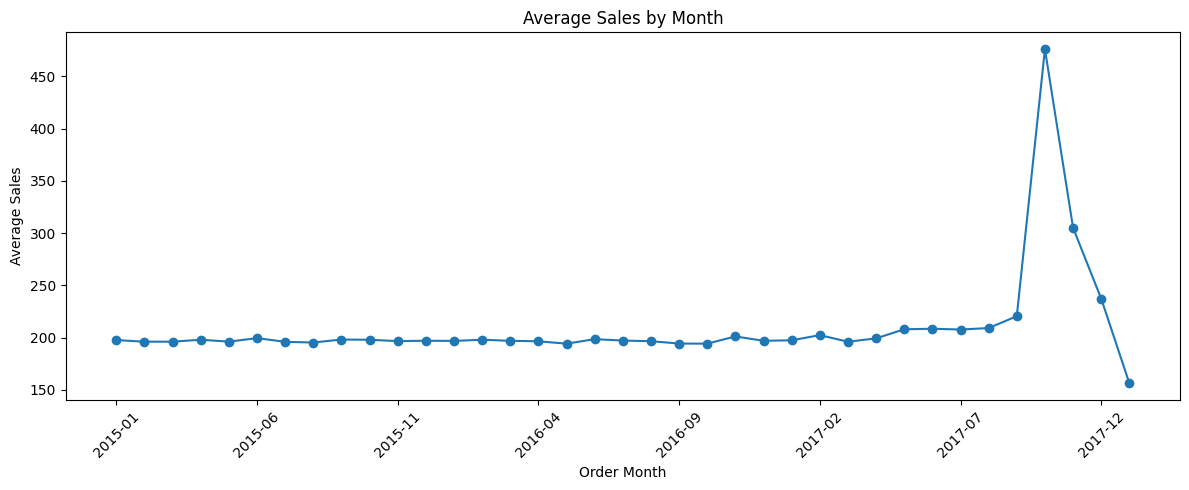

In [37]:
sales_by_month.plot(
    kind='line',
    figsize=(12, 5),
    marker='o'
)

plt.title('Average Sales by Month')
plt.xlabel('Order Month')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Monthly Record Count

In [38]:
records_by_month = df.groupby('Order_Month').size()

records_by_month

Order_Month
2015-01    5322
2015-02    4729
2015-03    5362
2015-04    5126
2015-05    5357
2015-06    5134
2015-07    5299
2015-08    5273
2015-09    5140
2015-10    5302
2015-11    5235
2015-12    5371
2016-01    5317
2016-02    4894
2016-03    5210
2016-04    5097
2016-05    5302
2016-06    5054
2016-07    5305
2016-08    5334
2016-09    5160
2016-10    5398
2016-11    5210
2016-12    5269
2017-01    5217
2017-02    4906
2017-03    5347
2017-04    5212
2017-05    5317
2017-06    4951
2017-07    5318
2017-08    5305
2017-09    5189
2017-10    2255
2017-11    2055
2017-12    2124
2018-01    2123
dtype: int64

### Total Sales by Month

In [40]:
total_sales_by_month = (
    df.groupby('Order_Month')['Sales']
    .sum()
)

total_sales_by_month.round(2)

Order_Month
2015-01    1051590.08
2015-02     927009.90
2015-03    1051253.69
2015-04    1014463.28
2015-05    1050478.44
2015-06    1024006.17
2015-07    1038081.19
2015-08    1029494.69
2015-09    1018338.60
2015-10    1049154.27
2015-11    1029120.24
2015-12    1057840.88
2016-01    1046308.25
2016-02     968542.85
2016-03    1025853.12
2016-04    1001211.58
2016-05    1029400.20
2016-06    1003059.55
2016-07    1045715.62
2016-08    1048200.25
2016-09    1002397.04
2016-10    1048130.55
2016-11    1047590.14
2016-12    1037408.17
2017-01    1029698.02
2017-02     992534.90
2017-03    1048004.78
2017-04    1038321.62
2017-05    1105485.32
2017-06    1032086.49
2017-07    1104373.36
2017-08    1109337.17
2017-09    1143775.11
2017-10    1073994.17
2017-11     626914.38
2017-12     503910.82
2018-01     331650.12
Name: Sales, dtype: float64

### Median Sales by Month

In [41]:
median_sales_by_month = (
    df.groupby('Order_Month')['Sales']
    .median()
)

median_sales_by_month.round(2)

Order_Month
2015-01    199.92
2015-02    179.97
2015-03    179.97
2015-04    199.92
2015-05    179.97
2015-06    199.92
2015-07    179.97
2015-08    179.97
2015-09    179.97
2015-10    199.92
2015-11    179.97
2015-12    179.97
2016-01    179.97
2016-02    199.92
2016-03    179.97
2016-04    179.97
2016-05    179.97
2016-06    179.97
2016-07    199.92
2016-08    179.97
2016-09    179.97
2016-10    179.97
2016-11    199.92
2016-12    179.97
2017-01    179.97
2017-02    199.92
2017-03    179.97
2017-04    199.92
2017-05    199.95
2017-06    199.95
2017-07    199.95
2017-08    199.98
2017-09    199.99
2017-10    357.10
2017-11    260.65
2017-12    164.38
2018-01     84.40
Name: Sales, dtype: float64

### Sales Anomaly Finding

Average Sales show a substantial spike from October 2017 onward. The elevated median Sales in October 2017 (357.10), alongside the mean of 476.27, indicates that the increase is not solely driven by a small number of extreme values. This period also coincides with a substantial reduction in monthly record counts, suggesting a change in the underlying data distribution that warrants further investigation.

### Average Profit by Month

In [42]:
profit_by_month = (
    df.groupby('Order_Month')['Order Profit Per Order']
    .mean()
)

profit_by_month.round(2)

Order_Month
2015-01    20.98
2015-02    20.96
2015-03    21.22
2015-04    21.09
2015-05    20.93
2015-06    21.45
2015-07    21.82
2015-08    22.37
2015-09    22.08
2015-10    19.19
2015-11    19.95
2015-12    20.60
2016-01    20.08
2016-02    17.74
2016-03    19.44
2016-04    22.56
2016-05    20.88
2016-06    20.62
2016-07    22.61
2016-08    20.76
2016-09    23.91
2016-10    21.63
2016-11    21.02
2016-12    19.93
2017-01    22.01
2017-02    23.46
2017-03    22.20
2017-04    22.25
2017-05    21.63
2017-06    22.30
2017-07    21.25
2017-08    24.79
2017-09    23.60
2017-10    50.31
2017-11    32.99
2017-12    31.00
2018-01    15.94
Name: Order Profit Per Order, dtype: float64

### Profit Finding

Average profit remains relatively stable for most of the observed period, generally ranging between 20 and 24. A substantial increase occurs in October 2017, reaching 50.31, followed by 32.99 in November and 31.00 in December. Average profit then declines to 15.94 in January 2018. The late-2017 changes coincide with the reduction in monthly record counts and should therefore be interpreted with caution.

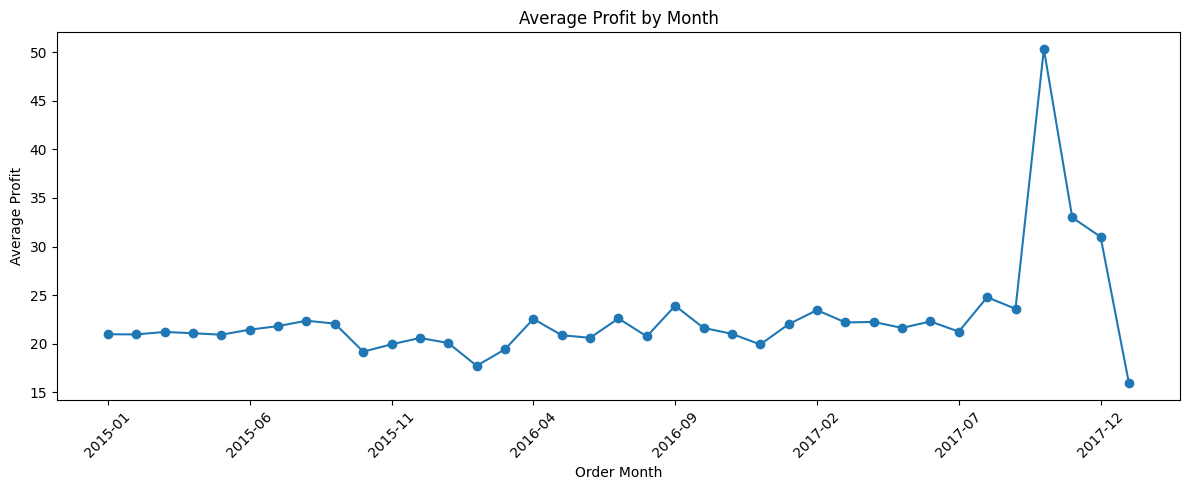

In [43]:
profit_by_month.plot(
    kind='line',
    figsize=(12, 5),
    marker='o'
)

plt.title('Average Profit by Month')
plt.xlabel('Order Month')
plt.ylabel('Average Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Total Profit by Month

In [44]:
total_profit_by_month = (
    df.groupby('Order_Month')['Order Profit Per Order']
    .sum()
)

total_profit_by_month.round(2)

Order_Month
2015-01    111660.74
2015-02     99140.66
2015-03    113778.21
2015-04    108083.68
2015-05    112147.90
2015-06    110147.16
2015-07    115624.06
2015-08    117979.77
2015-09    113467.94
2015-10    101757.87
2015-11    104427.36
2015-12    110641.55
2016-01    106780.95
2016-02     86809.49
2016-03    101259.99
2016-04    114976.62
2016-05    110716.12
2016-06    104196.07
2016-07    119941.72
2016-08    110729.54
2016-09    123384.71
2016-10    116781.97
2016-11    109539.20
2016-12    105002.69
2017-01    114843.85
2017-02    115111.07
2017-03    118688.90
2017-04    115961.06
2017-05    115014.64
2017-06    110399.29
2017-07    113026.70
2017-08    131501.16
2017-09    122462.39
2017-10    113447.17
2017-11     67791.25
2017-12     65837.63
2018-01     33841.89
Name: Order Profit Per Order, dtype: float64

### Total Profit Finding

Total monthly profit generally follows the number of records in each month. Although October 2017 has a substantially higher average profit of 50.31, its total profit of 113,447.17 remains comparable to earlier months because the number of records dropped considerably. This indicates that the late-2017 increase in average profit does not represent a proportional increase in total monthly profit.

### Time-Based Analysis Summary

Monthly late-delivery rates remain relatively stable throughout the observed period, generally staying in the mid-50% range without a clear long-term trend. Average Sales and average profit also remain relatively stable for most of the period but show substantial increases in October 2017. This period coincides with a significant reduction in monthly record counts, while total Sales and total profit remain relatively high compared with the reduced number of records. Therefore, the late-2017 increase in average Sales and profit should be interpreted cautiously rather than as a direct indication of improved overall business performance.

## 7. Financial Analysis

### Overall Sales and Profit

In [45]:
total_sales = df['Sales'].sum()
total_profit = df['Order Profit Per Order'].sum()

total_sales, total_profit

(np.float64(36784735.01337984), np.float64(3966902.974050357))

### Overall Financial Finding

The dataset records total Sales of 36.78 million and total profit of 3.97 million across all observations. These figures provide an overall view of the financial scale of the business represented in the dataset.

### Overall Profit Margin

In [46]:
profit_margin = (total_profit / total_sales) * 100

round(profit_margin, 2)


np.float64(10.78)

### Total Profit by Product Category

In [47]:
profit_by_category = (
    df.groupby('Category Name')['Order Profit Per Order']
    .sum()
    .sort_values(ascending=False)
)

profit_by_category.head(10).round(2)

Category Name
Fishing                 756220.77
Cleats                  494636.92
Camping & Hiking        427455.57
Cardio Equipment        383011.10
Women's Apparel         350421.03
Water Sports            325146.96
Indoor/Outdoor Games    318451.43
Men's Footwear          311902.82
Shop By Sport           129813.96
Computers                69656.81
Name: Order Profit Per Order, dtype: float64

### Profitability Finding

The top 10 product categories by total profit largely correspond to the top 10 categories by total Sales. Fishing generates the highest total profit at 756,220.77, followed by Cleats at 494,636.92 and Camping & Hiking at 427,455.57. This indicates that the major Sales-generating categories are also the major contributors to total profit in this dataset.

### Top 10 Categories by Total Profit

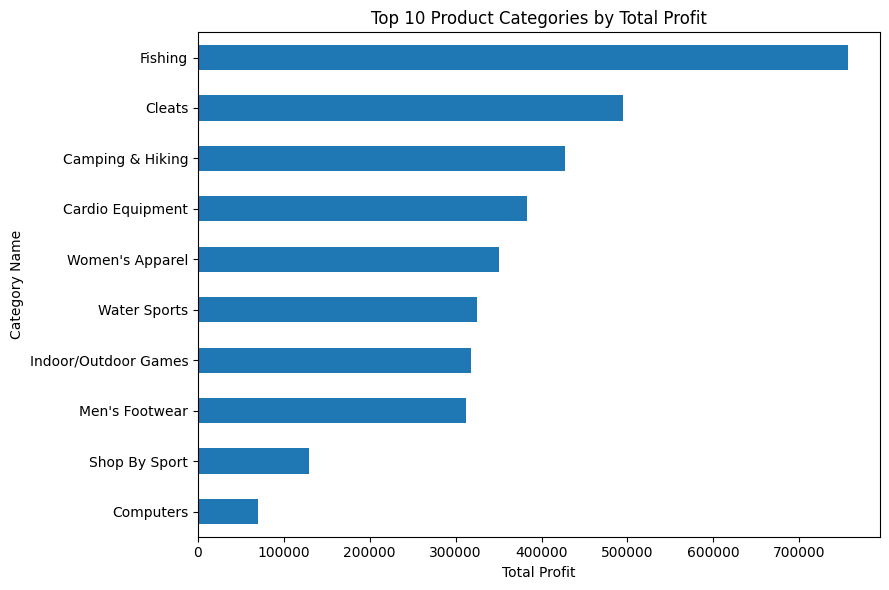

In [48]:
profit_by_category.head(10).sort_values().plot(
    kind='barh',
    figsize=(9, 6)
)

plt.title('Top 10 Product Categories by Total Profit')
plt.xlabel('Total Profit')
plt.ylabel('Category Name')
plt.tight_layout()
plt.show()


### Total Profit by Shipping Mode

In [50]:
profit_by_shipping = (
    df.groupby('Shipping Mode')['Order Profit Per Order']
    .sum()
    .sort_values(ascending=False)
)

profit_by_shipping.round(2)


Shipping Mode
Standard Class    2370454.45
Second Class       750308.17
First Class        643121.92
Same Day           203018.43
Name: Order Profit Per Order, dtype: float64

### Shipping Mode Profitability Finding

Standard Class generates the highest total profit at 2,370,454.45, followed by Second Class, First Class, and Same Day. However, this differs from average profit per order, where First Class had the highest average. This difference suggests that Standard Class's high total profit is primarily associated with its larger volume of orders rather than the highest profit per individual order.

### Profit Margin by Product Category

In [51]:
category_financials = (
    df.groupby('Category Name')
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Order Profit Per Order', 'sum')
    )
)

category_financials['Profit_Margin'] = (
    category_financials['Total_Profit'] /
    category_financials['Total_Sales']
) * 100

category_financials['Profit_Margin'].sort_values(
    ascending=False
).head(10).round(2)


Category Name
Golf Bags & Carts      17.46
Fitness Accessories    14.77
Toys                   14.75
Soccer                 14.74
Women's Clothing       13.62
Baseball & Softball    13.57
Garden                 12.97
Tennis & Racquet       12.89
Music                  12.76
CDs                    12.55
Name: Profit_Margin, dtype: float64

### Profit Margin by Shipping Mode

In [52]:
shipping_financials = (
    df.groupby('Shipping Mode')
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Order Profit Per Order', 'sum')
    )
)

shipping_financials['Profit_Margin'] = (
    shipping_financials['Total_Profit'] /
    shipping_financials['Total_Sales']
) * 100

shipping_financials['Profit_Margin'].sort_values(
    ascending=False
).round(2)

Shipping Mode
First Class       11.33
Standard Class    10.76
Second Class      10.50
Same Day          10.45
Name: Profit_Margin, dtype: float64

### Shipping Mode Profitability Finding

First Class has the highest profit margin at 11.33%, while Same Day has the lowest at 10.45%. However, the difference of 0.88 percentage points is relatively small, indicating that profit margins are broadly similar across shipping modes. Although Standard Class generates the highest total profit, First Class has the highest profit margin relative to its Sales.


### Sales vs Profitability by Product Category

In [53]:
category_financials.sort_values(
    'Total_Sales',
    ascending=False
).head(10).round(2)

,Total_Sales,Total_Profit,Profit_Margin
Category Name,,,
Fishing,6929653.69,756220.77,10.91
Cleats,4431942.78,494636.92,11.16
Camping & Hiking,4118425.57,427455.57,10.38
Cardio Equipment,3694843.20,383011.10,10.37
Women's Apparel,3147800.00,350421.03,11.13
Water Sports,3113844.68,325146.96,10.44
Men's Footwear,2891757.66,311902.82,10.79
Indoor/Outdoor Games,2888993.91,318451.43,11.02
Shop By Sport,1309522.04,129813.96,9.91


### Sales and Profitability Finding

Among the top 10 categories ranked by Total Sales, Fishing generates the highest Sales and total profit. Profit margins within these high-Sales categories range from 9.91% to 11.16%, showing that high Sales volume does not necessarily result in the highest profit margin. The highest overall category profit margin was observed separately for Golf Bags & Carts at 17.46%.

## 8. Relationship Analysis


### Sales vs Profit Relationship

In [54]:
sales_profit_corr = df[
    ['Sales', 'Order Profit Per Order']
].corr()

sales_profit_corr

,Sales,Order Profit Per Order
Sales,1.000000,0.131816
Order Profit Per Order,0.131816,1.000000


### Correlation Finding

Sales and Order Profit Per Order show a weak positive correlation of 0.13. This indicates that higher Sales are associated with only a slight tendency toward higher profit, suggesting that Sales alone is not a strong indicator of profit per order in this dataset.

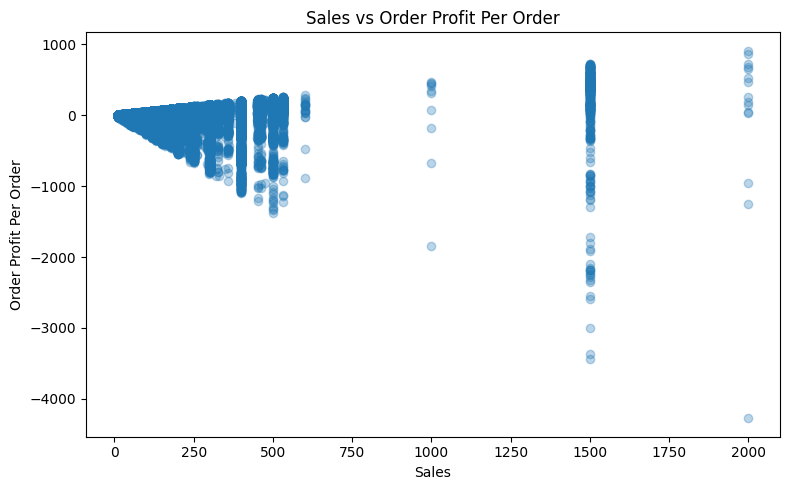

In [55]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Sales'],
    df['Order Profit Per Order'],
    alpha=0.3
)

plt.title('Sales vs Order Profit Per Order')
plt.xlabel('Sales')
plt.ylabel('Order Profit Per Order')
plt.tight_layout()
plt.show()

### Shipping Delay vs Profit Relationship

In [56]:
delay_profit_corr = df[
    ['Shipping_Delay_Days', 'Order Profit Per Order']
].corr()

delay_profit_corr

,Shipping_Delay_Days,Order Profit Per Order
Shipping_Delay_Days,1.000000,-0.005385
Order Profit Per Order,-0.005385,1.000000


### Correlation Finding

Shipping Delay Days and Order Profit Per Order show an extremely weak negative correlation of -0.005. Since the value is very close to zero, there is essentially no linear relationship between shipping delay and profit per order in this dataset.

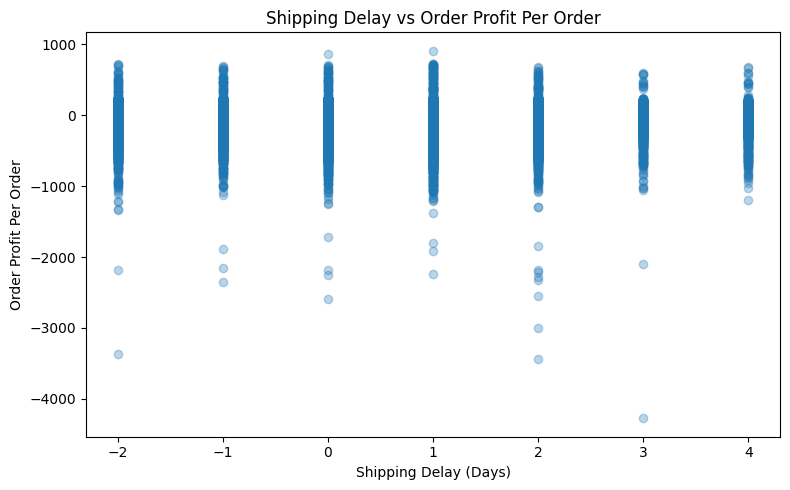

In [57]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Shipping_Delay_Days'],
    df['Order Profit Per Order'],
    alpha=0.3
)

plt.title('Shipping Delay vs Order Profit Per Order')
plt.xlabel('Shipping Delay (Days)')
plt.ylabel('Order Profit Per Order')
plt.tight_layout()
plt.show()

### Sales vs Shipping Delay Relationship

In [58]:
sales_delay_corr = df[
    ['Sales', 'Shipping_Delay_Days']
].corr()

sales_delay_corr

,Sales,Shipping_Delay_Days
Sales,1.000000,-0.003695
Shipping_Delay_Days,-0.003695,1.000000


### Correlation Finding

Sales and Shipping Delay Days show an extremely weak negative correlation of -0.004. Since the value is very close to zero, there is essentially no linear relationship between Sales and shipping delay in this dataset.

### Relationship Analysis Summary

The relationship analysis shows that Sales and Order Profit Per Order have a weak positive correlation of 0.13, indicating that higher Sales are associated with only a slight tendency toward higher profit per order. Shipping Delay Days shows essentially no linear relationship with either Order Profit Per Order (-0.005) or Sales (-0.004). Overall, the analyzed numerical variables do not show strong linear relationships with one another.

## 9. Key Business Insights & Recommendations

This section summarizes the major findings from the exploratory data analysis and translates them into actionable business insights.

### Insight 1 — Delivery Performance

The analysis shows that late-delivery risk remains around the mid-50% range across the observed period, indicating that delivery delays are a significant operational issue. Late-delivery rates also vary across shipping modes, regions, and product categories, suggesting that delivery performance is not uniform across the business.

**Recommendation:** The business should identify high-risk shipping modes, regions, and product categories and investigate the operational factors contributing to their higher late-delivery rates.

### Insight 2 — Shipping Mode Profitability

Standard Class generates the highest total profit, while First Class has the highest profit margin. This indicates that total profitability and profitability per unit of Sales can produce different rankings. Standard Class appears to contribute strongly to overall profit through its larger business volume, whereas First Class generates a slightly higher profit relative to its Sales.

**Recommendation:** The business should evaluate shipping modes using both total profit and profit margin rather than relying on a single financial metric.

### Insight 3 — Product Category Performance

Fishing is the leading product category in both Total Sales and Total Profit, making it the strongest contributor to overall financial volume. However, the highest profit margin is observed in Golf Bags & Carts at 17.46%, showing that the category with the highest Sales or total profit is not necessarily the most profitable relative to its Sales. This highlights the importance of evaluating product categories using both financial volume and profitability efficiency.

**Recommendation:** The business should continue monitoring high-volume categories such as Fishing for their contribution to overall profit while also evaluating high-margin categories such as Golf Bags & Carts for opportunities to improve profitability and potentially expand their contribution.

### Insight 4 — Customer Segment Performance

Customer segments show relatively similar performance across late-delivery rate, average Sales, and average profit. Consumer customers have the highest average Sales (204.22) and average profit (22.18), while Home Office has the lowest values (202.34 and 21.44), but the differences are small. Late-delivery rates are also very similar across all three segments.

**Recommendation:** Customer segment does not appear to be a major differentiating factor in this dataset. Business decisions should therefore consider other factors, such as product category, shipping mode, and region, rather than relying heavily on customer segment alone.


### Insight 5 — Late-2017 Data Anomaly

A substantial change is observed from October 2017 onward. Monthly records declined sharply, with October 2017 containing 2,255 records compared with 5,189 in September. At the same time, average Sales increased from 220.42 to 476.27 and average profit increased from 23.60 to 50.31, while total Sales and total profit remained relatively high. This indicates that the increase in average values is strongly influenced by the reduced number of records rather than a proportional increase in total financial performance.

**Recommendation:** The late-2017 period should be investigated further to determine whether the reduction in records resulted from a change in data collection, business operations, or another underlying factor before using these months for trend-based business decisions.

### Insight 6 — Relationships Between Key Variables

The correlation analysis shows that Sales and Order Profit Per Order have only a weak positive relationship (0.13), while Shipping Delay Days has essentially no linear relationship with either Order Profit Per Order (-0.005) or Sales (-0.004). This suggests that Sales alone does not strongly explain profit per order, and shipping delay does not show a meaningful linear association with either financial performance measure.

**Recommendation:** Business decisions should avoid relying on a single numerical variable as a predictor of another. Profitability and delivery performance should instead be evaluated using multiple factors such as product category, shipping mode, region, and order characteristics.

## 10. Overall Conclusion



The exploratory data analysis provides an overall view of delivery performance, financial performance, product categories, customer segments, regional patterns, and relationships between key variables.

The analysis shows that late-delivery risk remains relatively high and varies across shipping modes, regions, and product categories. Standard Class contributes the highest total profit, while First Class has the highest profit margin among shipping modes. At the product-category level, Fishing generates the highest Total Sales and total profit, whereas Golf Bags & Carts has the highest profit margin.

Customer segments show relatively similar performance across Sales, profit, and late-delivery risk, suggesting that customer segment is not a major differentiating factor in this dataset. The time-based analysis also identifies an unusual pattern from October 2017 onward, where record counts decrease substantially while average Sales and profit increase. This should be investigated further before drawing conclusions about business growth during this period.

Finally, correlation analysis shows only a weak relationship between Sales and profit per order and essentially no linear relationship between shipping delay and either Sales or profit. Overall, the analysis suggests that business performance should be evaluated across multiple dimensions rather than relying on a single metric.

### Business Recommendations

1. **Improve delivery performance:** Investigate shipping modes, regions, and product categories with higher late-delivery rates to identify operational improvement opportunities.

2. **Monitor shipping profitability:** Evaluate shipping modes using both total profit and profit margin. Standard Class is the largest contributor to total profit, while First Class has the highest profit margin.

3. **Focus on product profitability:** Continue monitoring high-volume categories such as Fishing while identifying opportunities to scale high-margin categories such as Golf Bags & Carts.

4. **Use multiple customer and operational factors:** Customer segments show limited differences in this analysis, so decisions should also consider product, region, shipping mode, and other order-level characteristics.

5. **Investigate the late-2017 data anomaly:** Review the sharp reduction in records from October 2017 onward to determine whether it reflects a data-collection change, operational change, or another underlying factor.

6. **Avoid single-variable conclusions:** The weak correlations indicate that Sales, profit, and shipping delay should not be interpreted in isolation. Business decisions should consider multiple relevant variables together.